<a href="https://colab.research.google.com/github/oliviapang/demand_estimation_project/blob/main/1_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 1: Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [2]:
df = pd.read_csv('./air_fryers_clean_brand_year.csv')

**1. Verify that the data contain 10 brands and the years 2019-2023.**

In [3]:
print(df.shape)
print(df.head())

(50, 15)
     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119      

In [27]:
print(df['brand'].unique())
print(df['year'].unique())

['chefman' 'cosori' 'cuisinart' 'dash' 'gowise usa' 'instant_pot' 'ninja'
 'nuwave' 'oster' 'ultrean']
[2019 2020 2021 2022 2023]


There are 10 brands: Chefman, Cosori, Cuisinart, Dash, Gowise USA, Instant Pot, Ninja, Nuwave, Oster, and Ultrean.
There are five years, spanning from 2019 to 2023.

**2. Plot the following over time by brand: average price, average rating, brand market share**

<Axes: xlabel='year', ylabel='avg_price'>

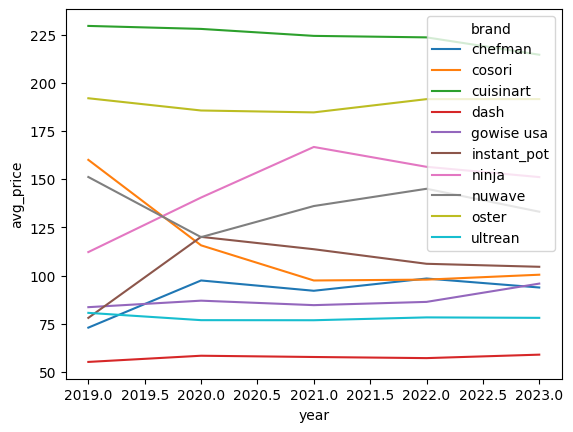

In [48]:
sns.lineplot(x = df['year'], y = df['avg_price'], hue = df['brand'])

<Axes: xlabel='year', ylabel='avg_rating'>

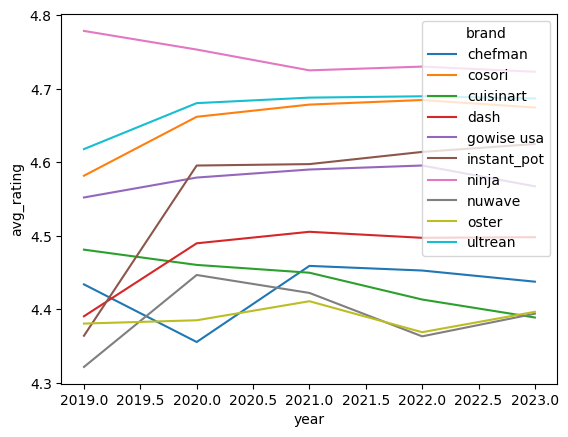

In [49]:
sns.lineplot(x = df['year'], y = df['avg_rating'], hue = df['brand'])

<Axes: xlabel='year', ylabel='brand_share'>

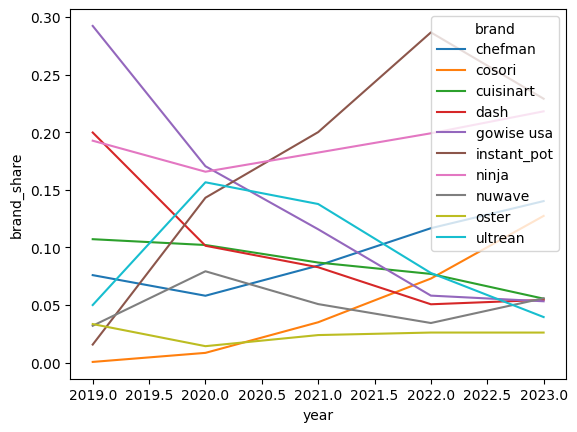

In [50]:
sns.lineplot(x = df['year'], y = df['brand_share'], hue = df['brand'])

**3. Summarize the product characteristics: Which features are common? Which features are rare? Are there brands that seem to specialize in different product types?**

In [40]:
df.columns
features = ['compact_share', 'dual_basket_share',
       'oven_style_share', 'rotisserie_share', 'window_share']

In [43]:
df[features].mean().sort_values()

,0
dual_basket_share,0.002260
window_share,0.036741
rotisserie_share,0.070762
oven_style_share,0.562647
compact_share,0.980081


In [47]:
df.groupby('brand')[features].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


The most common features are compact and oven style, as over half of the airfyers on the market posses those features. The rotisserie, window, and dual basket features are more rare; any one of these rare features is found in less than 10% of the products on the market. Cuisinart, Dash, Oster, and Ultrean specialize in oven style products. Chefman stands out as the only brand having a significant share of products with the rotisserie and window share. Cosori, Gowise USA, and Ninja all have low shares in oven style, indiciating that they probabily specialize in more standard setup air fryers.

**4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?**

In the air fryer market, Cuisinart maintains a fairly constant average price at the top of the price range, followed by Oster; Dash consistently has the lowest price. Ultrean and Gowise USA also remain on the lower end of the price range. From around 2019-2020 Cosori and Nuwave have higher average prices than Ninja and Instant Pot; however, these two pairs switch places after 2020. Ninja has the highest ranking across all years, followed by Ultrean and Cosori. Interestingly, some of the most expensive brands (e.g. Oster and Cuisinart) have some of the lowest average ratings across all years. In 2019, Gowise made up nearly 30% of the air fryer market. However, this share dropped steadily through 2023, where it makes up about 15%. In contrast, Instant Pot holds a small share in 2019 but climbs to nearly 30% in 2022. As of 2023, Instant Pot and Ninja dominate the market. Overall, the market appears relatively unstable. Barring a couple brands (Ninja, Oster, and potentially Nuwave), market shares change pretty drastically, indicating changes in consumer preference and brand competition.

# **Part 2: Demand Estimation**

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

feature_cols = [
    'compact_share', 'dual_basket_share', 'oven_style_share',
    'rotisserie_share', 'window_share'
 ]

y = df['log_brand_share']
brand_dummies = pd.get_dummies(df['brand'], prefix='brand', drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str), prefix='year', drop_first=True, dtype=int)

X = pd.concat([df[['avg_price', 'avg_rating'] + feature_cols], brand_dummies, year_dummies], axis=1)

model = LinearRegression()
model.fit(X, y)
predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', ascending=False)

price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
rating_coef = coef_table.loc[coef_table['feature'] == 'avg_rating', 'coefficient'].iloc[0]
feature_coef_table = coef_table[coef_table['feature'].isin(feature_cols)]
brand_coef_table = coef_table[coef_table['feature'].str.startswith('brand_')]
year_coef_table = coef_table[coef_table['feature'].str.startswith('year_')]

print("price coefficient:", price_coef)
print("rating coefficient:", rating_coef)
print("r2:", r2)
print("feature coefficients:")
print(feature_coef_table)
print("brand coefficients:")
print(brand_coef_table)
print("year coefficients:")
print(year_coef_table)

price coefficient: -0.03766765298429371
rating coefficient: 0.2875168474327454
r2: 0.763453950091436
feature coefficients:
             feature  coefficient
6       window_share    12.880298
2      compact_share     9.815304
4   oven_style_share     1.941774
5   rotisserie_share    -5.674054
3  dual_basket_share    -9.509686
brand coefficients:
              feature  coefficient
8     brand_cuisinart     6.422436
12        brand_ninja     5.838705
11  brand_instant_pot     4.626260
10   brand_gowise usa     3.938996
14        brand_oster     3.928074
13       brand_nuwave     3.544883
7        brand_cosori     2.551946
15      brand_ultrean     0.942399
9          brand_dash     0.176655
year coefficients:
      feature  coefficient
16  year_2020     0.119071
17  year_2021     0.041900
19  year_2023    -0.003307
18  year_2022    -0.098860


**Part 2 Answers**

1. Estimated price coefficient: **$\hat{\beta}_{price} = -0.0377$**.
2. Yes, it is negative, which is what we want. If price goes up, demand should go down.
3. Positive feature coefficients are `window_share`, `compact_share`, and `oven_style_share`. The negative ones are`rotisserie_share` and `dual_basket_share`.
4. Biggest brand dummy coefficients are `brand_cuisinart`, `brand_ninja`, and `brand_instant_pot`.
5. Biggest year effects are 2020 and 2021.
6. R^2 is approx. 0.7635.

# **Part 3: Strategy (Costs, Markups, and Profit)**

price coefficient: -0.03766765298429371
number of negative inferred unit costs: 0
brand strategy summary:
         brand   unit_cost     markup  average_profit  avg_rating   avg_price
6        ninja  112.488470  32.854071        6.306093    4.742064  145.342541
5  instant_pot   71.903119  32.558234        6.010256    4.559323  104.461353
4   gowise usa   56.301040  31.153741        4.605764    4.576990   87.454781
3         dash   27.936578  29.542349        2.994372    4.476394   57.478927
0      chefman   61.569466  29.368946        2.820968    4.427966   90.938411
9      ultrean   48.785765  29.328841        2.780864    4.672616   78.114606
2    cuisinart  194.896119  29.050974        2.502997    4.438892  223.947093
1       cosori   86.283321  27.984628        1.436651    4.656292  114.267950
7       nuwave  109.053549  27.970835        1.422858    4.389798  137.024384
8        oster  161.804969  27.226315        0.678338    4.388653  189.031284


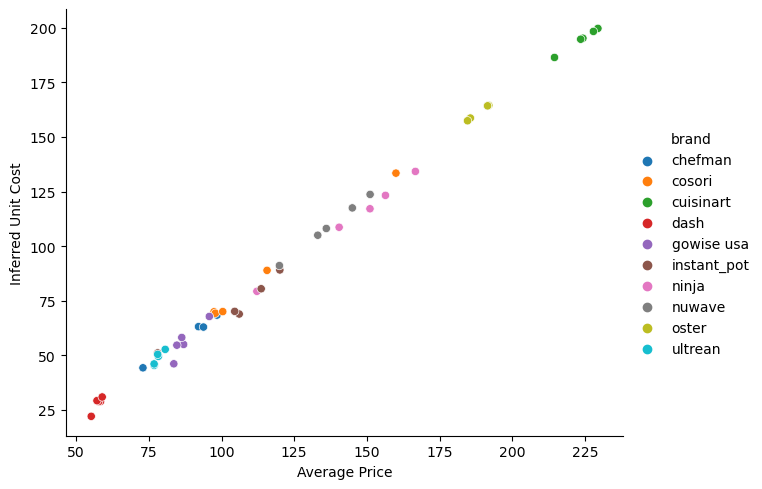

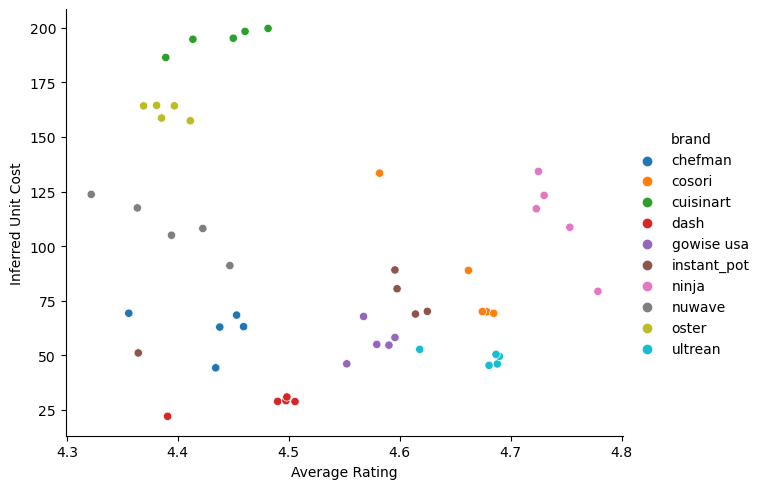

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


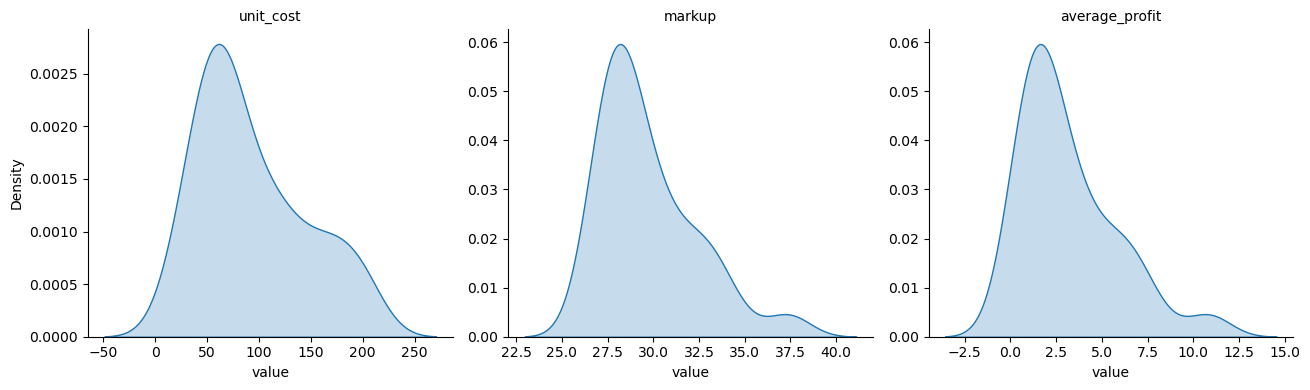

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


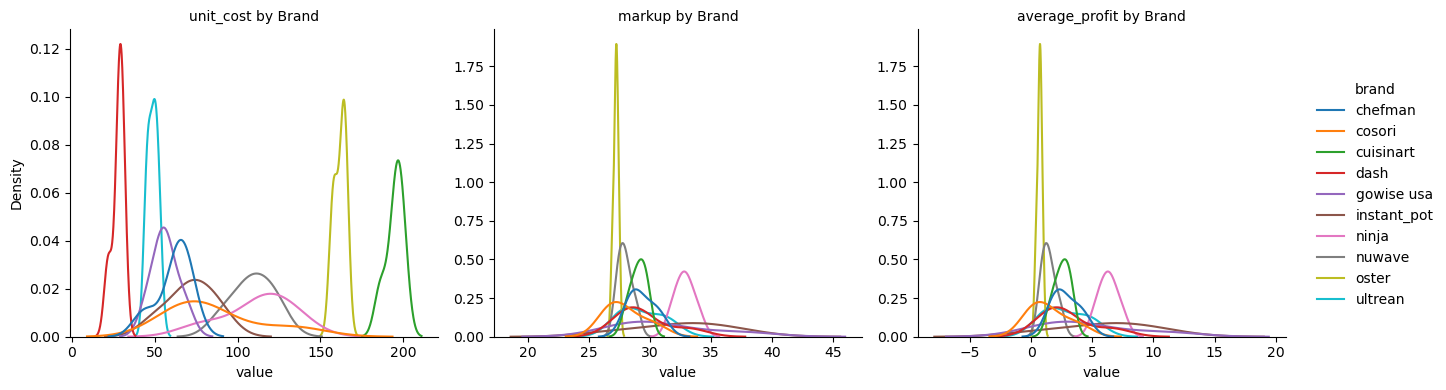

Top brands by share-weighted average profit:
         brand  average_profit
6        ninja        6.306093
5  instant_pot        6.010256
4   gowise usa        4.605764
3         dash        2.994372
0      chefman        2.820968
9      ultrean        2.780864
2    cuisinart        2.502997
1       cosori        1.436651
7       nuwave        1.422858
8        oster        0.678338
Avg_price corr with unit cost: 0.9987615477618677
Avg_rating corr with unit cost: -0.3139327100646513


In [5]:
results = df.copy()
results['predicted_log_share'] = predicted_log_share
results['demand_slope'] = price_coef * results['brand_share'] * (1 - results['brand_share'])
results['unit_cost'] = results['avg_price'] + results['brand_share'] / results['demand_slope']
results['markup'] = results['avg_price'] - results['unit_cost']
results['average_profit'] = results['brand_share'] * results['markup']

brand_strategy_summary = (
    results.groupby('brand', as_index=False)[['unit_cost', 'markup', 'average_profit', 'avg_rating', 'avg_price']]
    .mean()
    .sort_values('average_profit', ascending=False)
)

print('price coefficient:', price_coef)
print('number of negative inferred unit costs:', (results['unit_cost'] < 0).sum())
print('brand strategy summary:')
print(brand_strategy_summary)

g = sns.relplot(
    data=results, x='avg_price', y='unit_cost', hue='brand',
    kind='scatter', height=5, aspect=1.3
 )
g.set_axis_labels('Average Price', 'Inferred Unit Cost')
plt.show()
g = sns.relplot(
    data=results, x='avg_rating', y='unit_cost', hue='brand',
    kind='scatter', height=5, aspect=1.3
 )
g.set_axis_labels('Average Rating', 'Inferred Unit Cost')
plt.show()

plot_long = results.melt(
    id_vars=['brand'],
    value_vars=['unit_cost', 'markup', 'average_profit'],
    var_name='metric',
    value_name='value'
)

g = sns.displot(
    data=plot_long, x='value', col='metric', kind='kde', fill=True,
    facet_kws={'sharex': False, 'sharey': False},
    height=4, aspect=1.1
)
g.set_titles('{col_name}')
plt.show()

g = sns.displot(
    data=plot_long, x='value', col='metric', hue='brand', kind='kde',
    common_norm=False,
    facet_kws={'sharex': False, 'sharey': False},
    height=4, aspect=1.1
)
g.set_titles('{col_name} by Brand')
plt.show()

print('Top brands by share-weighted average profit:')
print(brand_strategy_summary[['brand', 'average_profit']])
print('Avg_price corr with unit cost:', results['avg_price'].corr(results['unit_cost']))
print('Avg_rating corr with unit cost:', results['avg_rating'].corr(results['unit_cost']))

**Part 3 Answers**

1. The table shows average unit costs and markups by brand.
2. No negative inferred unit costs.
3. The highest average unit costs are mainly Cuisinart, Oster, and Ninja. Price and unit cost move almost at the same rate, indicating a strong positive relationship, but rating and unit cost does not seem to have much of a relationship. This goes to show that the cost of a product does not dictate its quality or customer satisfactory. The more expensive products from CuisinArt are at the lower end of the average rating range. 
4. The KDE plots are in the code above.
5. The top brands in share-weighted average profit are Ninja, Instant Pot, and GoWise USA.

Overall, brands with bigger market share plus solid markups end up with the highest share-weighted profits.